In [2]:
import pickle
import pandas as pd
import numpy as np
import operator
from numba import njit

In [3]:
ot = pd.read_pickle("pickles/sept.pickle")
nt = pd.read_pickle("pickles/tisch.pickle")
bible = pd.concat([ot, nt], axis=0, ignore_index=True)
strongs = pd.read_pickle("pickles/strongs.pickle")

In [4]:
with open("references-naive.pickle", "rb") as f:
    found = pickle.load(f)

found = sorted(found, key=operator.itemgetter(0))

# quote start, quote end, source start, source end
found = [((nloc, nloc + nlen), (oloc, oloc + olen)) for nloc, nlen, oloc, olen in found]

In [5]:
@njit
def locs_overlap(loc1, loc2):
    s1, e1 = loc1
    s2, e2 = loc2
    return s1 <= s2 <= e1 or s2 <= s1 <= e2


@njit
def refs_overlap(ref1, ref2):
    nloc1, oloc1 = ref1
    nloc2, oloc2 = ref2
    return locs_overlap(nloc1, nloc2) and locs_overlap(oloc1, oloc2)


@njit
def merge_locs(loc1, loc2):
    s1, e1 = loc1
    s2, e2 = loc2
    return min(s1, s2), max(e1, e2)


@njit
def merge_refs(ref1, ref2):
    nloc1, oloc1 = ref1
    nloc2, oloc2 = ref2
    return merge_locs(nloc1, nloc2), merge_locs(oloc1, oloc2)


@njit
def mergify(found):
    repass = True
    while repass:
        merged = []
        repass = False
        deleted = [False] * len(found)
        for ridx1, ref1 in enumerate(found):
            if deleted[ridx1]:
                continue
            for ridx2 in range(ridx1 + 1, len(found)):
                ref2 = found[ridx2]
                if refs_overlap(ref1, ref2):
                    if deleted[ridx2]:
                        repass = True
                        continue
                    ref1 = merge_refs(ref1, ref2)
                    deleted[ridx2] = True
            merged.append(ref1)
        found = merged
    return merged

In [6]:
merged = mergify(found)
len(merged)

4807

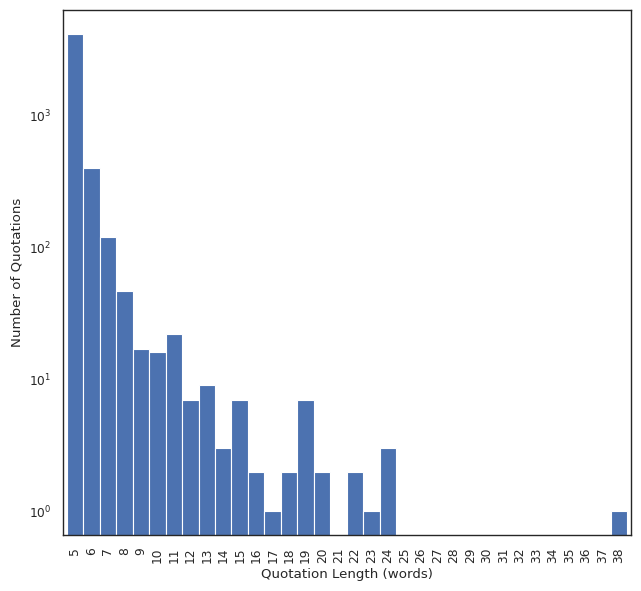

In [23]:
import seaborn as sns

sns.set_theme(context="paper", style="white")

stuff = references["nlen"].value_counts().sort_index()
for i in range(5, 39):
    try:
        stuff[i]
    except KeyError:
        stuff[i] = 0
ax = stuff.sort_index().plot.bar(
    logy=True, width=1, ylabel="Number of Quotations", xlabel="Quotation Length (words)"
)
ax.figure.set_size_inches(6.5, 6)
ax.figure.tight_layout()
ax.figure.savefig("nlen.png")

In [10]:
references = pd.DataFrame(
    columns=["nstart", "nlen", "nend", "ostart", "olen", "oend"], dtype=int
)
for (nstart, nend), (ostart, oend) in merged:
    references.loc[len(references)] = [
        nstart,
        nend - nstart,
        nend,
        ostart,
        oend - ostart,
        oend,
    ]

#### Saving References in a useful format to a pickle.

In [7]:
with open("pickles/references.pickle", "wb") as f:
    pickle.dump(references, f)

In [9]:
bible_books = [
    "Genesis",
    "Exodus",
    "Leviticus",
    "Numbers",
    "Deuteronomy",
    "Joshua",
    "Judges",
    "Ruth",
    "1 Samuel",
    "2 Samuel",
    "1 Kings",
    "2 Kings",
    "1 Chronicles",
    "2 Chronicles",
    "Ezra",
    "Nehemiah",
    "Esther",
    "Job",
    "Psalms",
    "Proverbs",
    "Ecclesiastes",
    "Song of Solomon",
    "Isaiah",
    "Jeremiah",
    "Lamentations",
    "Ezekiel",
    "Daniel",
    "Hosea",
    "Joel",
    "Amos",
    "Obadiah",
    "Jonah",
    "Micah",
    "Nahum",
    "Habakkuk",
    "Zephaniah",
    "Haggai",
    "Zechariah",
    "Malachi",
    "Matthew",
    "Mark",
    "Luke",
    "John",
    "Acts",
    "Romans",
    "1 Corinthians",
    "2 Corinthians",
    "Galatians",
    "Ephesians",
    "Philippians",
    "Colossians",
    "1 Thessalonians",
    "2 Thessalonians",
    "1 Timothy",
    "2 Timothy",
    "Titus",
    "Philemon",
    "Hebrews",
    "James",
    "1 Peter",
    "2 Peter",
    "1 John",
    "2 John",
    "3 John",
    "Jude",
    "Revelation",
]
bible_books = pd.Series(bible_books)

In [10]:
bible_books[:3]

0      Genesis
1       Exodus
2    Leviticus
dtype: object

In [11]:
bible_tuple = bible[["verse", "chapter", "book"]]
verse_dict = pd.Series(
    zip(
        bible_books.loc[bible_tuple["book"] - 1],
        bible_tuple["chapter"],
        bible_tuple["verse"],
    )
)

In [12]:
references["nstart"]

0       475406
1       475421
2       475429
3       475564
4       475565
         ...  
4802    612901
4803    612901
4804    612901
4805    612901
4806    612901
Name: nstart, Length: 4807, dtype: int64

In [13]:
verse_dict.iloc[references["nend"]].index.duplicated().any()

True

In [14]:
references2 = pd.DataFrame(index=references.index)
references2["n_start"] = verse_dict.iloc[references["nstart"]].reset_index(drop=True)
references2["n_end"] = verse_dict.iloc[references["nend"]].reset_index(drop=True)
references2["o_start"] = verse_dict.iloc[references["ostart"]].reset_index(drop=True)
references2["o_end"] = verse_dict.iloc[references["oend"]].reset_index(drop=True)

In [15]:
references2

,n_start,n_end,o_start,o_end
0,"(Matthew, 1, 1)","(Matthew, 1, 2)","(Genesis, 25, 19)","(Genesis, 25, 20)"
1,"(Matthew, 1, 2)","(Matthew, 1, 3)","(Genesis, 44, 14)","(Genesis, 44, 14)"
2,"(Matthew, 1, 3)","(Matthew, 1, 3)","(1 Chronicles, 2, 4)","(1 Chronicles, 2, 4)"
3,"(Matthew, 1, 11)","(Matthew, 1, 11)","(1 Chronicles, 26, 26)","(1 Chronicles, 26, 26)"
4,"(Matthew, 1, 11)","(Matthew, 1, 11)","(1 Chronicles, 9, 32)","(1 Chronicles, 9, 32)"
...,...,...,...,...
4802,"(Revelation, 22, 19)","(Revelation, 22, 19)","(Deuteronomy, 30, 10)","(Deuteronomy, 30, 10)"
4803,"(Revelation, 22, 19)","(Revelation, 22, 19)","(Joshua, 23, 6)","(Joshua, 23, 6)"
4804,"(Revelation, 22, 19)","(Revelation, 22, 20)","(2 Chronicles, 34, 21)","(2 Chronicles, 34, 22)"
4805,"(Revelation, 22, 19)","(Revelation, 22, 19)","(2 Chronicles, 34, 24)","(2 Chronicles, 34, 24)"


In [16]:
import plotly.express as px

In [17]:
(references2["n_start"]).str[0]

0          Matthew
1          Matthew
2          Matthew
3          Matthew
4          Matthew
           ...    
4802    Revelation
4803    Revelation
4804    Revelation
4805    Revelation
4806    Revelation
Name: n_start, Length: 4807, dtype: object

In [18]:
book_authors = {
    "Genesis": "Moses",
    "Exodus": "Moses",
    "Leviticus": "Moses",
    "Numbers": "Moses",
    "Deuteronomy": "Moses",
    "Joshua": "Joshua",
    "Judges": "Samuel; Nathan; Gad",
    "Ruth": "Samuel",
    "1 Samuel": "Samuel; Nathan; Gad",
    "2 Samuel": "Gad; Nathan",
    "1 Kings": "Jeremiah",
    "2 Kings": "Jeremiah",
    "1 Chronicles": "Ezra",
    "2 Chronicles": "Ezra",
    "Ezra": "Ezra",
    "Nehemiah": "Nehemiah",
    "Esther": "Mordecai",
    "Job": "Unknown",
    "Psalms": "David and others",
    "Proverbs": "Solomon; Agur; Lemuel",
    "Ecclesiastes": "Solomon",
    "Song of Songs": "Solomon",
    "Isaiah": "Isaiah",
    "Jeremiah": "Jeremiah",
    "Lamentations": "Jeremiah",
    "Ezekiel": "Ezekiel",
    "Daniel": "Daniel",
    "Hosea": "Hosea",
    "Joel": "Joel",
    "Amos": "Amos",
    "Obadiah": "Obadiah",
    "Jonah": "Jonah",
    "Micah": "Micah",
    "Nahum": "Nahum",
    "Habakkuk": "Habakkuk",
    "Zephaniah": "Zephaniah",
    "Haggai": "Haggai",
    "Zechariah": "Zechariah",
    "Malachi": "Malachi",
    "Matthew": "Matthew",
    "Mark": "Mark",
    "Luke": "Luke",
    "John": "John",
    "Acts": "Luke",
    "Romans": "Paul",
    "1 Corinthians": "Paul",
    "2 Corinthians": "Paul",
    "Galatians": "Paul",
    "Ephesians": "Paul",
    "Philippians": "Paul",
    "Colossians": "Paul",
    "1 Thessalonians": "Paul",
    "2 Thessalonians": "Paul",
    "1 Timothy": "Paul",
    "2 Timothy": "Paul",
    "Titus": "Paul",
    "Philemon": "Paul",
    "Hebrews": "Unknown",
    "James": "James",
    "1 Peter": "Peter",
    "2 Peter": "Peter",
    "1 John": "John",
    "2 John": "John",
    "3 John": "John",
    "Jude": "Jude",
    "Revelation": "John",
}

In [19]:
px.histogram(x=references2["n_start"].str[0], labels={"x": "Book of the Bible"})

In [20]:
px.histogram(x=references2["n_start"].str[0].map(book_authors), labels={"x": "Authors"})

#### Most quoted verse in the Bible: 
1. "Love the Lord your God with all your heart and with all your soul and with all your mind and with all your strength.’"
2. "“The virgin will conceive and give birth to a son, and they will call him Immanuel”[a] (which means “God with us”)"
3. "He answered, “‘Love the Lord your God with all your heart and with all your soul and with all your strength and with all your mind’; and, ‘Love your neighbor as yourself."
4. "He answered, “‘Love the Lord your God with all your heart and with all your soul and with all your strength and with all your mind’; and, ‘Love your neighbor as yourself."


In [21]:
entire_allusions = (
    (references2["n_start"] + references2["n_end"]).value_counts().to_frame()
)

In [22]:
entire_allusions.index = pd.Series(entire_allusions.index).apply(
    lambda x: x[0] + ":" + str(x[1]) + ":" + str(x[-1])
)

#### Saving the bible with tuple index

In [23]:
bible["book"] = bible_books.loc[bible["book"] - 1].values
bible.index = pd.Series(zip(bible["book"], bible["chapter"], bible["verse"]))
bible.index = pd.MultiIndex.from_tuples(bible.index, names=["book", "chapter", "verse"])
with open("./pickles/bible.pickle", "wb") as f:
    pickle.dump(bible, f)
bible

text   str  verse  chapter        book      rmac
book       chapter verse                                                      
Genesis    1       1            εν  1722      1        1     Genesis      prep
                   1          αρχη   746      1        1     Genesis     n-dsf
                   1      εποιησεν  4160      1        1     Genesis  v-aai-3s
                   1             ο  3588      1        1     Genesis     t-nsm
                   1          θεος  2316      1        1     Genesis     n-nsm
...                            ...   ...    ...      ...         ...       ...
Revelation 22      21          τοῦ  3588     21       22  Revelation     t-gsm
                   21       κυρίου  2962     21       22  Revelation     n-gsm
                   21        ἰησοῦ  2424     21       22  Revelation     n-gsm
                   21         μετὰ  3326     21       22  Revelation      prep
                   21       πάντων  3956     21       22  Revelation     a-gpm

[612925 rows x 6 columns]

In [24]:
bible.loc[("Genesis", 1)].head(3)

/tmp/ipykernel_650076/3741901978.py:1: PerformanceWarning:

indexing past lexsort depth may impact performance.



,text,str,verse,chapter,book,rmac
verse,,,,,,
1,εν,1722,1,1,Genesis,prep
1,αρχη,746,1,1,Genesis,n-dsf
1,εποιησεν,4160,1,1,Genesis,v-aai-3s


#### Saving references2

In [25]:
" ".join(bible.loc[("Genesis", 1, 1)]["text"].values)

/tmp/ipykernel_650076/3086043418.py:1: PerformanceWarning:

indexing past lexsort depth may impact performance.



'εν αρχη εποιησεν ο θεος τον ουρανον και την γην'

In [26]:
bible

text   str  verse  chapter        book      rmac
book       chapter verse                                                      
Genesis    1       1            εν  1722      1        1     Genesis      prep
                   1          αρχη   746      1        1     Genesis     n-dsf
                   1      εποιησεν  4160      1        1     Genesis  v-aai-3s
                   1             ο  3588      1        1     Genesis     t-nsm
                   1          θεος  2316      1        1     Genesis     n-nsm
...                            ...   ...    ...      ...         ...       ...
Revelation 22      21          τοῦ  3588     21       22  Revelation     t-gsm
                   21       κυρίου  2962     21       22  Revelation     n-gsm
                   21        ἰησοῦ  2424     21       22  Revelation     n-gsm
                   21         μετὰ  3326     21       22  Revelation      prep
                   21       πάντων  3956     21       22  Revelation     a-gpm

[612925 rows x 6 columns]

In [27]:
bible_by_verse = bible.groupby(level=[0, 1, 2], sort=False)["text"].agg(
    lambda x: " ".join(x)
)

In [28]:
references2.head(5)

,n_start,n_end,o_start,o_end
0,"(Matthew, 1, 1)","(Matthew, 1, 2)","(Genesis, 25, 19)","(Genesis, 25, 20)"
1,"(Matthew, 1, 2)","(Matthew, 1, 3)","(Genesis, 44, 14)","(Genesis, 44, 14)"
2,"(Matthew, 1, 3)","(Matthew, 1, 3)","(1 Chronicles, 2, 4)","(1 Chronicles, 2, 4)"
3,"(Matthew, 1, 11)","(Matthew, 1, 11)","(1 Chronicles, 26, 26)","(1 Chronicles, 26, 26)"
4,"(Matthew, 1, 11)","(Matthew, 1, 11)","(1 Chronicles, 9, 32)","(1 Chronicles, 9, 32)"


In [29]:
references2["new_text"] = references2.apply(
    lambda row: " ".join(bible_by_verse[row["n_start"] : row["n_end"]]), axis=1
)
references2["old_text"] = references2.apply(
    lambda row: " ".join(bible_by_verse[row["o_start"] : row["o_end"]]), axis=1
)

In [32]:
references2

,n_start,n_end,o_start,o_end,new_text,old_text
0,"(Matthew, 1, 1)","(Matthew, 1, 2)","(Genesis, 25, 19)","(Genesis, 25, 20)",βίβλος γενέσεως ἰησοῦ χριστοῦ υἱοῦ δαυεὶδ υἱοῦ...,και αυται αι γενεσεις ισαακ του υιου αβρααμ αβ...
1,"(Matthew, 1, 2)","(Matthew, 1, 3)","(Genesis, 44, 14)","(Genesis, 44, 14)",ἀβραὰμ ἐγέννησεν τὸν ἰσαάκ ἰσαὰκ δὲ ἐγέννησεν ...,εισηλθεν δε ιουδας και οι αδελφοι αυτου προς ι...
2,"(Matthew, 1, 3)","(Matthew, 1, 3)","(1 Chronicles, 2, 4)","(1 Chronicles, 2, 4)",ἰούδας δὲ ἐγέννησεν τὸν φάρες καὶ τὸν ζάρα ἐκ ...,και θαμαρ η νυμφη αυτου ετεκεν αυτω τον φαρες ...
3,"(Matthew, 1, 11)","(Matthew, 1, 11)","(1 Chronicles, 26, 26)","(1 Chronicles, 26, 26)",ἰωσείας δὲ ἐγέννησεν τὸν ἰεχονίαν καὶ τοὺς ἀδε...,αυτος σαλωμωθ και οι αδελφοι αυτου επι παντων ...
4,"(Matthew, 1, 11)","(Matthew, 1, 11)","(1 Chronicles, 9, 32)","(1 Chronicles, 9, 32)",ἰωσείας δὲ ἐγέννησεν τὸν ἰεχονίαν καὶ τοὺς ἀδε...,και βαναιας ο κααθιτης εκ των αδελφων αυτων επ...
...,...,...,...,...,...,...
4802,"(Revelation, 22, 19)","(Revelation, 22, 19)","(Deuteronomy, 30, 10)","(Deuteronomy, 30, 10)",καὶ ἐάν τις ἀφέλῃ ἀπὸ τῶν λόγων τοῦ βιβλίου τῆ...,εαν εισακουσης της φωνης κυριου του θεου σου φ...
4803,"(Revelation, 22, 19)","(Revelation, 22, 19)","(Joshua, 23, 6)","(Joshua, 23, 6)",καὶ ἐάν τις ἀφέλῃ ἀπὸ τῶν λόγων τοῦ βιβλίου τῆ...,κατισχυσατε ουν σφοδρα φυλασσειν και ποιειν πα...
4804,"(Revelation, 22, 19)","(Revelation, 22, 20)","(2 Chronicles, 34, 21)","(2 Chronicles, 34, 22)",καὶ ἐάν τις ἀφέλῃ ἀπὸ τῶν λόγων τοῦ βιβλίου τῆ...,πορευθητε ζητησατε τον κυριον περι εμου και πε...
4805,"(Revelation, 22, 19)","(Revelation, 22, 19)","(2 Chronicles, 34, 24)","(2 Chronicles, 34, 24)",καὶ ἐάν τις ἀφέλῃ ἀπὸ τῶν λόγων τοῦ βιβλίου τῆ...,ουτως λεγει κυριος ιδου εγω επαγω κακα επι τον...


In [31]:
with open("pickles/references2.pickle", "wb") as f:
    pickle.dump(references2, f)